# 04 - Exploratory Data Analysis



In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 50)

from src.data.load_data import load_csv
from src.analysis.exploratory_analysis import correlation_matrix, top_correlated_with
from src.visualization.charts import plot_histogram, plot_boxplot, plot_correlation_heatmap
from src.utils.config import load_config, resolve_path

config = load_config()
df = load_csv(resolve_path(config['data']['interim_path']))
print(f"Working with cleaned dataset: {df.shape}")

%matplotlib inline

2026-09-20 22:16:33 | INFO     | src.data.load_data | Loaded CSV 'manufacturing_interim.csv' with shape (3240, 17)


Working with cleaned dataset: (3240, 17)


## Distribution of core variables

visualize the distribution of `ProductionVolume`, `ProductionCost`, `QualityScore`, and `DefectRate` to understand their typical shape (normal, skewed, uniform).

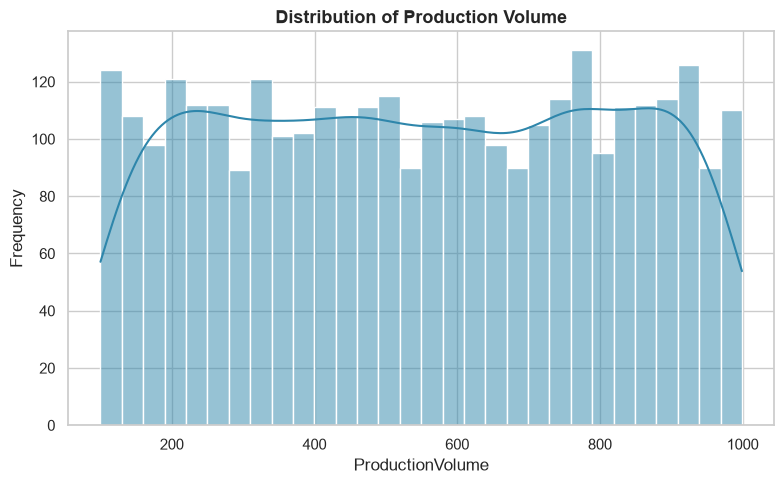

In [2]:
fig = plot_histogram(df, 'ProductionVolume', title='Distribution of Production Volume')
plt.show()

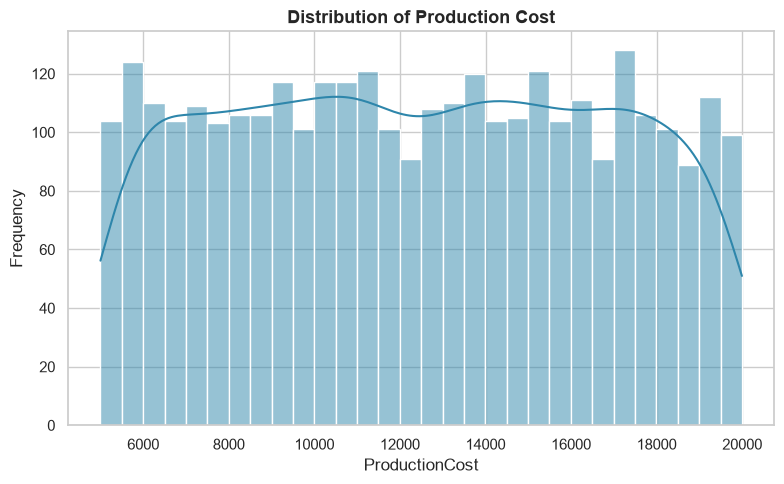

In [3]:
fig = plot_histogram(df, 'ProductionCost', title='Distribution of Production Cost')
plt.show()

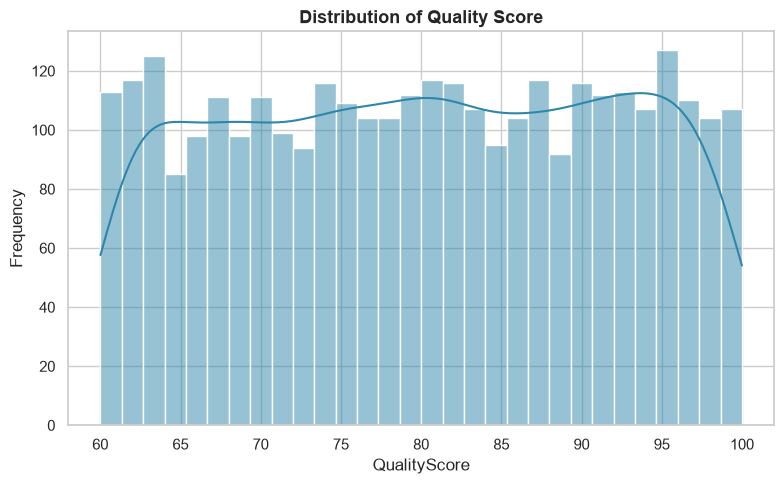

In [4]:
fig = plot_histogram(df, 'QualityScore', title='Distribution of Quality Score')
plt.show()

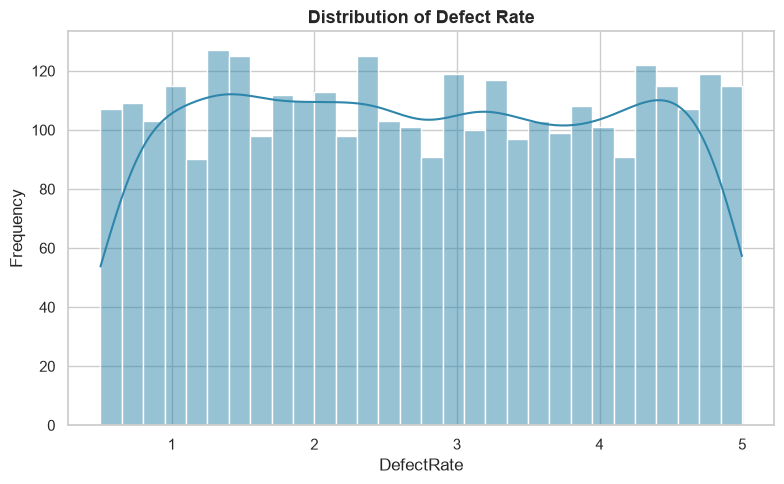

In [5]:
fig = plot_histogram(df, 'DefectRate', title='Distribution of Defect Rate')
plt.show()

**Interpretation:** `ProductionVolume` appears roughly uniform across its range (consistent with synthetic/simulated production batches). `ProductionCost` and `QualityScore` show broader, fairly even spreads as well, without a single dominant peak. `DefectRate` is right-skewed, with most records clustered at lower defect-rate values and a tail of higher values.

## Boxplots: comparing defective vs. non-defective records



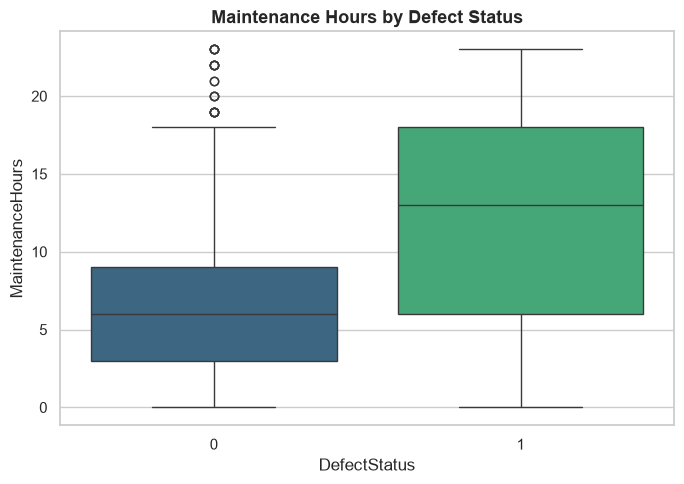

In [6]:
fig = plot_boxplot(df, 'MaintenanceHours', by='DefectStatus', title='Maintenance Hours by Defect Status')
plt.show()

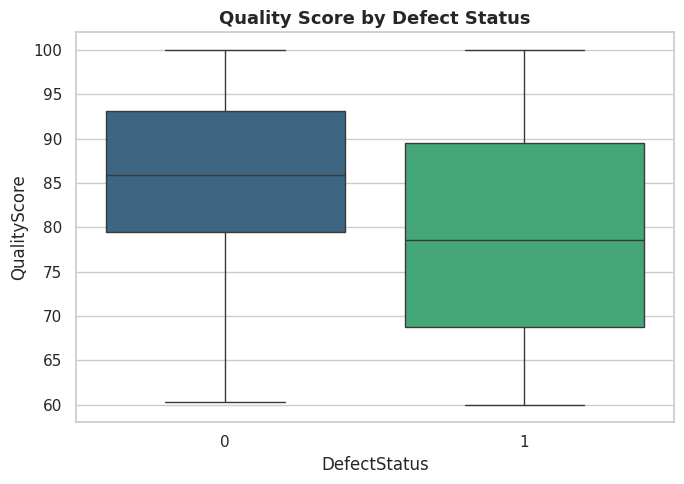

In [7]:
fig = plot_boxplot(df, 'QualityScore', by='DefectStatus', title='Quality Score by Defect Status')
plt.show()

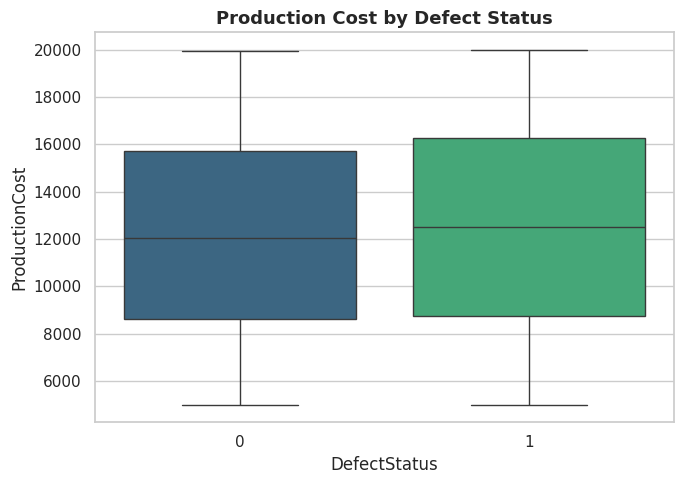

In [8]:
fig = plot_boxplot(df, 'ProductionCost', by='DefectStatus', title='Production Cost by Defect Status')
plt.show()

**Interpretation:** The `MaintenanceHours` boxplot shows a visibly higher median for defective records than for non-defective records - a first strong visual signal. `QualityScore` shows the opposite pattern (lower for defective records), which makes business sense: lower quality scores should coincide with more defects. `ProductionCost` shows a much smaller visual difference between the two groups.

## Correlation analysis



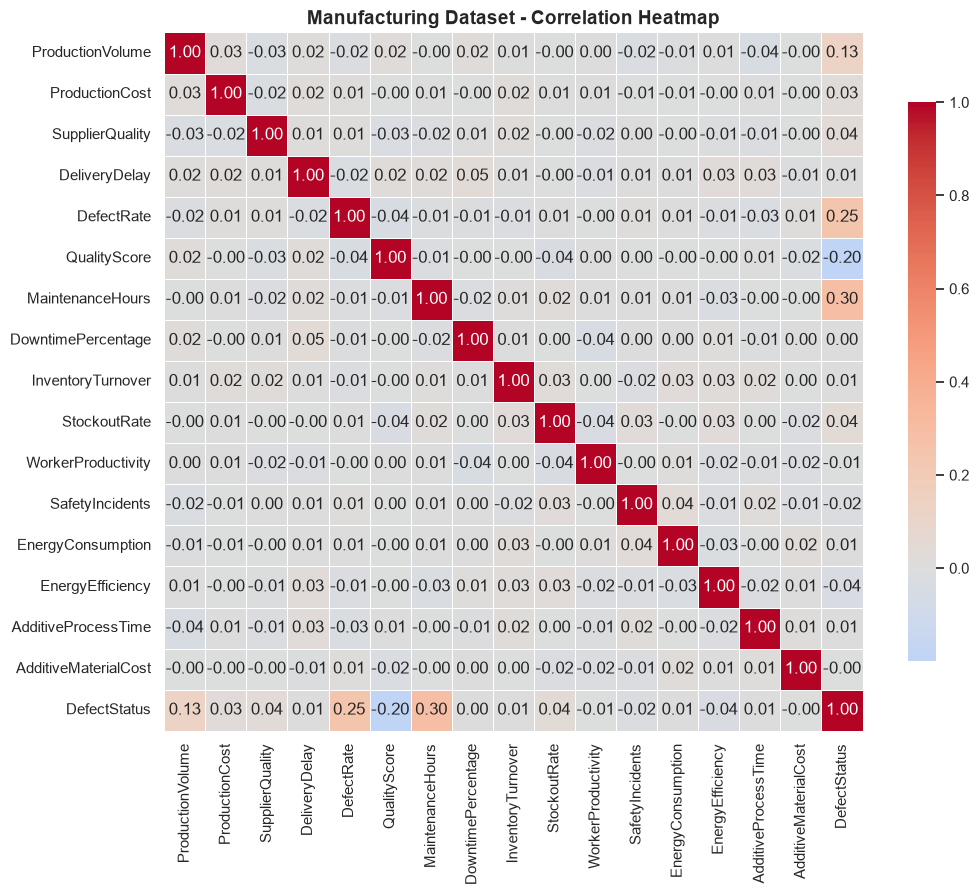

In [10]:
fig = plot_correlation_heatmap(df.select_dtypes(include='number'), title='Manufacturing Dataset - Correlation Heatmap')
plt.show()

## Top variables correlated with DefectStatus



In [10]:
top_corr_status = top_correlated_with(df, 'DefectStatus', n=10)
top_corr_status

MaintenanceHours     0.297107
DefectRate           0.245746
QualityScore        -0.199219
ProductionVolume     0.128973
StockoutRate         0.040574
SupplierQuality      0.038184
EnergyEfficiency    -0.035031
ProductionCost       0.026720
SafetyIncidents     -0.016039
InventoryTurnover    0.006733
Name: DefectStatus, dtype: float64

## Top variables correlated with DefectRate



In [8]:
top_corr_rate = top_correlated_with(df, 'DefectRate', n=10)
top_corr_rate

DefectStatus           0.245746
QualityScore          -0.036350
AdditiveProcessTime   -0.028426
DeliveryDelay         -0.023024
ProductionVolume      -0.019360
ProductionCost         0.014428
EnergyEfficiency      -0.014168
InventoryTurnover     -0.014148
SafetyIncidents        0.012196
SupplierQuality        0.012157
Name: DefectRate, dtype: float64

**Interpretation:** `MaintenanceHours` stands out as the variable most strongly (positively) correlated with both `DefectStatus` and `DefectRate` - more maintenance hours associate with a higher likelihood of defects, and `QualityScore` is the strongest negatively-correlated variable - higher quality scores associate with fewer defects. Most other variables (`ProductionCost`, `ProductionVolume`, `SupplierQuality`, `WorkerProductivity`, `EnergyConsumption`, etc.) show weak correlation with the defect outcome in this dataset.

## Summary of EDA findings

1. `ProductionVolume`, `ProductionCost`, and `QualityScore` are all fairly evenly spread across their ranges, with no dominant single value.
2. `DefectRate` is right-skewed.
3. `MaintenanceHours` shows the strongest positive association with defects; `QualityScore` shows the strongest negative association.
4. Most other operational variables show only weak correlation with the defect outcome in this dataset.
